# 10. Probability Calibration and Risk Scoring

A classifier can rank cases well and still produce poor probabilities. That distinction matters whenever predicted scores are used as **risk estimates** rather than just ordering devices. If a model says a portfolio contains 120 expected failures next week, or if an account is assigned a 0.42 probability of breach, those numbers should mean something operationally. Calibration is the discipline of checking whether they do.

This notebook studies probability calibration in a decision-science setting. We will distinguish **discrimination** from **calibration**, show how reliability diagrams and proper scoring rules diagnose probability quality, and then use post-hoc recalibration to improve risk estimates without retraining the underlying classifier. The framing follows classic work on supervised probability estimation and score recalibration (Zadrozny & Elkan, 2002; Niculescu-Mizil & Caruana, 2005; Fawcett & Niculescu-Mizil, 2007) and applied discussions of calibration as agreement between predicted probabilities and observed event frequencies (Chivers et al., 2014; Trottini et al., 2020).

## Learning Objectives

By the end of this lecture, you should be able to:

1. Explain why good ranking performance does not guarantee good probabilities.
2. Define calibration formally and connect it to reliability diagrams.
3. Distinguish among ROC/AUC, Brier score, log loss, and expected calibration error.
4. Explain how Platt scaling and isotonic regression recalibrate scores.
5. Use calibrated probabilities for portfolio planning, triage, and risk-band design.
6. Recognize when probability quality matters more than thresholded classification accuracy.


## 1. What It Means for a Risk Score to Be Calibrated

Suppose a model outputs a predicted probability \(\hat p(x)\in[0,1]\) for a binary event \(Y \in \{0,1\}\). A standard calibration target is

$$
\mathbb{P}(Y=1 \mid \hat p(X)=p) = p
$$

for all relevant values \(p\). In words: among cases assigned risk \(p\), about a fraction \(p\) should truly experience the event. Chivers, Leung, and Yan (2014) describe calibration as agreement between predicted probabilities and the true probabilities implied by the data-generating process, while Trottini et al. (2020) describe a well-calibrated model as one for which subjects assigned probability \(p\) experience the event roughly \(p\) proportion of the time.

This is different from **discrimination**. A model can rank positives above negatives accurately even if all of its probabilities are systematically too high or too low. Ranking metrics such as ROC AUC mainly ask whether higher-risk cases receive higher scores. Calibration metrics ask whether the scores themselves can be interpreted as probabilities.

### Mathematical Spine: Proper Scoring Rules and Recalibration Maps

For binary outcomes, one common probability score is the **Brier score**,

$$
\operatorname{Brier}(\hat p)
= \frac{1}{n}\sum_{i=1}^n (\hat p_i - y_i)^2,
$$

which penalizes probability forecasts for being far from the realized outcomes. A second common score is **log loss**,

$$
\operatorname{LogLoss}(\hat p)
= -\frac{1}{n}\sum_{i=1}^n
\Big[y_i \log(\hat p_i) + (1-y_i)\log(1-\hat p_i)\Big].
$$

Both are lower-is-better. They reward probability forecasts that are both discriminative and numerically credible.

A reliability diagram is a diagnostic version of the calibration condition above. If we divide the predictions into bins \(B_1, \ldots, B_K\), then for each bin we compare

$$
\bar p_k = \frac{1}{|B_k|}\sum_{i \in B_k} \hat p_i
\qquad \text{and} \qquad
\bar y_k = \frac{1}{|B_k|}\sum_{i \in B_k} y_i.
$$

Perfect calibration would place the points \((\bar p_k, \bar y_k)\) on the 45-degree line.

Post-hoc calibration introduces a mapping \(m\) from raw scores into revised probabilities,

$$
\tilde p_i = m(\hat p_i).
$$

Two classic choices are:

1. **Platt scaling / sigmoid calibration**, which fits a parametric logistic map,

$$
\tilde p_i = \sigma(a + b\,\mathrm{logit}(\hat p_i)),
$$

2. **Isotonic regression**, which fits a nondecreasing stepwise map \(m\).

Fawcett and Niculescu-Mizil (2007) describe isotonic calibration as finding a monotone transformation that minimizes scores such as the Brier score and cross-entropy, while Trottini et al. (2020) summarize Platt scaling as a parametric sigmoid recalibration and isotonic regression as a nonparametric nondecreasing recalibration function.

### Why Calibration Matters in Decision Science

If a score is used only to sort cases, then modest calibration error may be tolerable. But if the score is used to estimate workload, financial exposure, or expected intervention benefit, calibration becomes central. For a portfolio of \(n\) independent risk estimates, the expected number of events is naturally approximated by

$$
\mathbb{E}\left[\sum_{i=1}^n Y_i \mid X_1,\ldots,X_n\right]
\approx \sum_{i=1}^n \hat p_i.
$$

So a badly calibrated model distorts staffing plans, risk bands, and budget forecasts even if its ranking ability looks acceptable.


In [1]:
# Section focus: Why Calibration Matters in Decision Science.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.


import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, log_loss, roc_auc_score
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 200)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f"{x:,.3f}")

sns.set_theme(style='whitegrid', palette='crest')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 9


def sigmoid(x):
    """Map a linear score to a probability-like value for the notebook simulation.
    
    Parameters
    ----------
    x : object
        Numeric score, scalar, or array passed through the transformation in this helper.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the sigmoid calculation.
    """
    return 1 / (1 + np.exp(-x))


def safe_logit(p, eps=1e-6):
    """Carry out the safe logit step used in the 10. Probability Calibration and Risk Scoring workflow.
    
    Parameters
    ----------
    p : object
        Probability value used in the simulation, scoring rule, or diagnostic calculation.
    eps : object
        The eps setting that controls the safe logit calculation in this notebook.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the safe logit calculation.
    """
    p = np.clip(np.asarray(p), eps, 1 - eps)
    return np.log(p / (1 - p))


def expected_calibration_error(y_true, probs, n_bins=10):
    """Carry out the expected calibration error step used in the 10. Probability Calibration and Risk Scoring workflow.
    
    Parameters
    ----------
    y_true : object
        Observed target or outcome values used as ground truth for metric calculation.
    probs : object
        Predicted probabilities used by the decision rule.
    n_bins : object
        Count or size setting for the expected calibration error calculation.
    
    Returns
    -------
    object
        Intermediate result produced by the expected calibration error calculation and reused by later cells.
    """
    table = reliability_table(y_true, probs, n_bins=n_bins)
    return np.average(table['abs_gap'], weights=table['count'])


def reliability_table(y_true, probs, n_bins=10):
    """Carry out the reliability table step used in the 10. Probability Calibration and Risk Scoring workflow.
    
    Parameters
    ----------
    y_true : object
        Observed target or outcome values used as ground truth for metric calculation.
    probs : object
        Predicted probabilities used by the decision rule.
    n_bins : object
        Count or size setting for the reliability table calculation.
    
    Returns
    -------
    object
        Tabular or matrix-style object produced by the reliability table workflow for later analysis.
    """
    frame = pd.DataFrame({'y': np.asarray(y_true).astype(int), 'prob': np.asarray(probs)})
    unique_scores = frame['prob'].nunique()
    bins = max(2, min(n_bins, unique_scores))
    frame['bin'] = pd.qcut(frame['prob'], q=bins, duplicates='drop')
    grouped = (
        frame.groupby('bin', observed=False)
        .agg(
            predicted_prob=('prob', 'mean'),
            observed_rate=('y', 'mean'),
            count=('y', 'size'),
            min_prob=('prob', 'min'),
            max_prob=('prob', 'max'),
        )
        .reset_index(drop=True)
    )
    grouped['abs_gap'] = (grouped['predicted_prob'] - grouped['observed_rate']).abs()
    return grouped


def calibration_slope_intercept(y_true, probs):
    """Carry out the calibration slope intercept step used in the 10. Probability Calibration and Risk Scoring workflow.
    
    Parameters
    ----------
    y_true : object
        Observed target or outcome values used as ground truth for metric calculation.
    probs : object
        Predicted probabilities used by the decision rule.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    z = safe_logit(probs).reshape(-1, 1)
    model = LogisticRegression(C=1e6, solver='lbfgs', max_iter=4000)
    model.fit(z, np.asarray(y_true).astype(int))
    return float(model.coef_[0][0]), float(model.intercept_[0])


def probability_metrics(y_true, probs, n_bins=10):
    """Carry out the probability metrics step used in the 10. Probability Calibration and Risk Scoring workflow.
    
    Parameters
    ----------
    y_true : object
        Observed target or outcome values used as ground truth for metric calculation.
    probs : object
        Predicted probabilities used by the decision rule.
    n_bins : object
        Count or size setting for the probability metrics calculation.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    y_true = np.asarray(y_true).astype(int)
    probs = np.clip(np.asarray(probs), 1e-6, 1 - 1e-6)
    slope, intercept = calibration_slope_intercept(y_true, probs)
    return {
        'roc_auc': roc_auc_score(y_true, probs),
        'average_precision': average_precision_score(y_true, probs),
        'brier_score': np.mean((probs - y_true) ** 2),
        'log_loss': log_loss(y_true, probs),
        'ece': expected_calibration_error(y_true, probs, n_bins=n_bins),
        'mean_predicted_risk': probs.mean(),
        'prevalence': y_true.mean(),
        'calibration_slope': slope,
        'calibration_intercept': intercept,
    }


def fit_sigmoid_calibrator(raw_probs, y_true):
    """Fit the sigmoid calibrator model or object used in the 10. Probability Calibration and Risk Scoring analysis.
    
    Parameters
    ----------
    raw_probs : object
        Rate or probability parameter controlling this calculation.
    y_true : object
        Observed target or outcome values used as ground truth for metric calculation.
    
    Returns
    -------
    object
        Fitted model or pipeline used by later analysis cells.
    """
    x = safe_logit(raw_probs).reshape(-1, 1)
    model = LogisticRegression(C=1e6, solver='lbfgs', max_iter=4000)
    model.fit(x, np.asarray(y_true).astype(int))
    return model


def apply_sigmoid_calibrator(calibrator, raw_probs):
    """Carry out the apply sigmoid calibrator step used in the 10. Probability Calibration and Risk Scoring workflow.
    
    Parameters
    ----------
    calibrator : object
        Model object, learner, or pipeline being fitted, scored, or explained.
    raw_probs : object
        Rate or probability parameter controlling this calculation.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the apply sigmoid calibrator calculation.
    """
    x = safe_logit(raw_probs).reshape(-1, 1)
    return calibrator.predict_proba(x)[:, 1]


def fit_isotonic_calibrator(raw_probs, y_true):
    """Fit the isotonic calibrator model or object used in the 10. Probability Calibration and Risk Scoring analysis.
    
    Parameters
    ----------
    raw_probs : object
        Rate or probability parameter controlling this calculation.
    y_true : object
        Observed target or outcome values used as ground truth for metric calculation.
    
    Returns
    -------
    object
        Fitted model, transformer, or configuration object from the isotonic calibrator workflow.
    """
    iso = IsotonicRegression(y_min=0.0, y_max=1.0, out_of_bounds='clip')
    iso.fit(np.asarray(raw_probs), np.asarray(y_true).astype(int))
    return iso


def plot_reliability(ax, y_true, probs, title, color='#2a6f97', n_bins=10):
    """Draw the reliability figure for the 10. Probability Calibration and Risk Scoring analysis.
    
    Parameters
    ----------
    ax : object
        Matplotlib axis on which the plot is drawn.
    y_true : object
        Observed target or outcome values used as ground truth for metric calculation.
    probs : object
        Predicted probabilities used by the decision rule.
    title : object
        Title used to label the displayed result.
    color : object
        Display setting used to make the plot or table readable in the rendered notebook.
    n_bins : object
        Count or size setting for the reliability calculation.
    
    Returns
    -------
    object
        None. The function updates a plot, display object, or notebook state as its side effect.
    """
    table = reliability_table(y_true, probs, n_bins=n_bins)
    ax.plot([0, 1], [0, 1], '--', color='0.55', linewidth=1.2, label='Perfect calibration')
    ax.plot(table['predicted_prob'], table['observed_rate'], marker='o', color=color, linewidth=2)
    ax.scatter(
        table['predicted_prob'],
        table['observed_rate'],
        s=25 + 0.15 * table['count'],
        color=color,
        alpha=0.85,
        edgecolor='white',
        linewidth=0.6,
    )
    ax.set_title(title)
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Observed event rate')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)


def simulate_calibration_data(n_weeks=72, accounts_per_week=140, random_state=24):
    """Create a simulated calibration data set for the 10. Probability Calibration and Risk Scoring case study.
    
    Parameters
    ----------
    n_weeks : object
        Count or size setting for the calibration data calculation.
    accounts_per_week : object
        Count or size parameter controlling the scale of the simulation or calculation.
    random_state : object
        Random seed or generator control used to make results reproducible.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rng = np.random.default_rng(random_state)
    rows = []
    for week in range(n_weeks):
        release_wave = int(week % 9 in {0, 1, 2})
        macro_stress = 0.25 * np.sin(week / 6) + 0.15 * (week >= 50)
        for account_id in range(accounts_per_week):
            tier_score = np.clip(rng.beta(3.0, 2.2), 0, 1)
            tenure_months = rng.gamma(shape=4.3, scale=8.0)
            latent_distress = rng.normal(0, 1)
            payment_hold = rng.binomial(1, sigmoid(-2.4 + 1.0 * latent_distress + 0.8 * (1 - tier_score)))
            backlog_ratio = np.clip(
                0.16 + 0.09 * latent_distress + 0.10 * release_wave + 0.05 * macro_stress + rng.normal(0, 0.08),
                0.02,
                0.95,
            )
            usage_drop_30d = np.clip(
                0.04 + 0.05 * latent_distress + 0.08 * release_wave + 0.14 * backlog_ratio + rng.normal(0, 0.045),
                0,
                0.45,
            )
            csat_drop_90d = np.clip(0.02 + 0.05 * latent_distress + 0.06 * payment_hold + rng.normal(0, 0.03), 0, 0.45)
            minor_incidents_30d = rng.poisson(max(0.2, 0.8 + 2.5 * backlog_ratio + 1.1 * release_wave + 0.6 * latent_distress))
            self_service_failures_30d = rng.poisson(max(0.1, 0.4 + 2.2 * usage_drop_30d + 0.9 * payment_hold + 0.4 * release_wave + 0.3 * max(latent_distress, -0.6)))
            support_touch_count_30d = rng.poisson(max(0.1, 1.2 + 4.8 * backlog_ratio + 2.4 * usage_drop_30d + 0.8 * payment_hold + 0.5 * release_wave))
            renewal_window = rng.binomial(1, sigmoid(-1.2 + 0.8 * (tenure_months > 18) - 0.5 * tier_score))

            true_logit = (
                -3.55
                + 2.5 * backlog_ratio
                + 4.3 * usage_drop_30d
                + 0.55 * payment_hold
                + 0.40 * renewal_window
                + 0.045 * minor_incidents_30d
                + 0.085 * self_service_failures_30d
                + 0.022 * support_touch_count_30d
                + 0.70 * release_wave
                + 5.4 * csat_drop_90d
                + 1.05 * ((backlog_ratio > 0.54) and (release_wave == 1))
                + 0.95 * ((usage_drop_30d > 0.18) and (self_service_failures_30d >= 3))
                + 0.70 * ((support_touch_count_30d >= 8) and (tier_score < 0.45))
                + 0.25 * macro_stress
            )
            true_prob = sigmoid(true_logit)
            sla_breach_next_week = rng.binomial(1, true_prob)

            if release_wave and backlog_ratio > 0.52:
                operating_regime = 'Release stress'
            elif payment_hold and usage_drop_30d > 0.15:
                operating_regime = 'Admin friction'
            elif backlog_ratio > 0.42:
                operating_regime = 'High backlog'
            else:
                operating_regime = 'Routine'

            rows.append(
                {
                    'week': week,
                    'tier_score': tier_score,
                    'tenure_months': tenure_months,
                    'payment_hold': payment_hold,
                    'backlog_ratio': backlog_ratio,
                    'usage_drop_30d': usage_drop_30d,
                    'csat_drop_90d': csat_drop_90d,
                    'minor_incidents_30d': minor_incidents_30d,
                    'self_service_failures_30d': self_service_failures_30d,
                    'support_touch_count_30d': support_touch_count_30d,
                    'renewal_window': renewal_window,
                    'release_wave': release_wave,
                    'true_prob': true_prob,
                    'sla_breach_next_week': sla_breach_next_week,
                    'operating_regime': operating_regime,
                }
            )
    df = pd.DataFrame(rows)
    df['split'] = np.where(df['week'] < 48, 'Train', np.where(df['week'] < 60, 'Validation', 'Test'))
    return df


## 2. Synthetic Portfolio Risk-Scoring Dataset

We will stay in the support-operations world from the previous notebook, but now the question is probability-focused rather than threshold-focused:

> **What is the probability that an enterprise account will enter an SLA-breach state next week?**

That makes this a natural calibration problem because the scores can be used in several ways at once:

- **ranking** the riskiest accounts for outreach,
- **estimating portfolio workload** by summing predicted risks,
- **creating risk bands** for standard, enhanced, and specialist review,
- **budget planning** for intervention teams.

The synthetic data include both smooth risk drivers and threshold-like interactions. This matters because some model families can rank such cases well while still producing distorted probabilities.


,split,rows,breach_rate,average_true_prob,release_share,payment_hold_share
0,Test,1680,0.190,0.189,0.250,0.131
1,Train,6720,0.221,0.219,0.375,0.148
2,Validation,1680,0.190,0.196,0.250,0.149


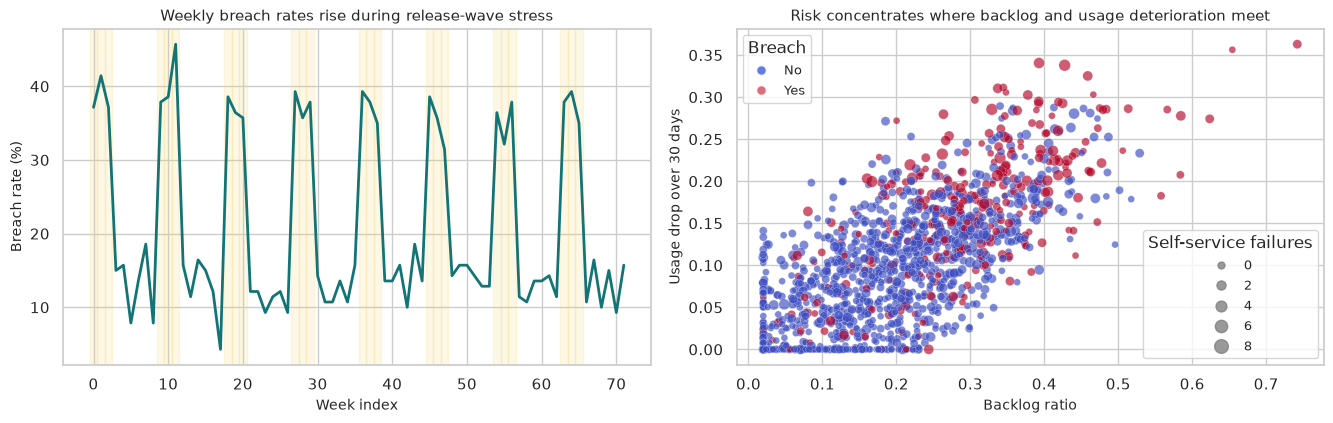

In [2]:
# Section focus: 2. Synthetic Portfolio Risk-Scoring Dataset.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.


df_risk = simulate_calibration_data()

prevalence_table = (
    df_risk.groupby('split', observed=False)
    .agg(
        rows=('sla_breach_next_week', 'size'),
        breach_rate=('sla_breach_next_week', 'mean'),
        average_true_prob=('true_prob', 'mean'),
        release_share=('release_wave', 'mean'),
        payment_hold_share=('payment_hold', 'mean'),
    )
    .reset_index()
)
display(prevalence_table)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))

weekly_actual = (
    df_risk.groupby('week', observed=False)
    .agg(
        breach_rate=('sla_breach_next_week', 'mean'),
        release_wave=('release_wave', 'max'),
    )
    .reset_index()
)

axes[0].plot(weekly_actual['week'], 100 * weekly_actual['breach_rate'], color='#127475', linewidth=2)
for _, row in weekly_actual.loc[weekly_actual['release_wave'] == 1].iterrows():
    axes[0].axvspan(row['week'] - 0.5, row['week'] + 0.5, color='#f4d35e', alpha=0.16)
axes[0].set_title('Weekly breach rates rise during release-wave stress')
axes[0].set_xlabel('Week index')
axes[0].set_ylabel('Breach rate (%)')

sample_plot = df_risk.sample(n=1400, random_state=9)
scatter = axes[1].scatter(
    sample_plot['backlog_ratio'],
    sample_plot['usage_drop_30d'],
    c=sample_plot['sla_breach_next_week'],
    cmap='coolwarm',
    s=25 + 9 * sample_plot['self_service_failures_30d'].clip(upper=8),
    alpha=0.65,
    edgecolor='white',
    linewidth=0.25,
)
axes[1].set_title('Risk concentrates where backlog and usage deterioration meet')
axes[1].set_xlabel('Backlog ratio')
axes[1].set_ylabel('Usage drop over 30 days')
breach_handles = [
    plt.Line2D([0], [0], marker='o', linestyle='', markersize=7, color='w', markerfacecolor='#3b5bdb', alpha=0.8),
    plt.Line2D([0], [0], marker='o', linestyle='', markersize=7, color='w', markerfacecolor='#d1495b', alpha=0.8),
]
legend1 = axes[1].legend(breach_handles, ['No', 'Yes'], title='Breach', loc='upper left', frameon=True)
axes[1].add_artist(legend1)

size_labels = [0, 2, 4, 6, 8]
size_handles = [
    plt.Line2D([0], [0], marker='o', linestyle='', markersize=np.sqrt(25 + 9 * s), color='gray', alpha=0.8)
    for s in size_labels
]
axes[1].legend(size_handles, [str(s) for s in size_labels], title='Self-service failures', loc='lower right', frameon=True)

plt.tight_layout()


The Synthetic Portfolio Risk-Scoring Dataset result matters when it changes the next move. A useful result points to a more defensible model or threshold choice.


### Discussion of the Data-Generating Process

The synthetic portfolio has three useful properties for studying calibration.

First, the event is neither too rare nor too common. That gives us enough positive cases to evaluate probabilities without turning every model into a near-trivial majority-class predictor.

Second, the true risk depends on interactions and regime changes. Release-wave weeks interact with backlog; high usage deterioration interacts with repeated self-service failure; and elevated support touch counts matter more for lower-tier accounts. This is exactly the kind of structure that can generate a separation between ranking quality and probability quality.

Third, the time index gives the probabilities operational meaning. Because cases arrive in weekly batches, we can later test whether summing predicted probabilities gives a sensible estimate of next week's expected number of breaches.


## 3. Strong Ranking Does Not Guarantee Strong Probabilities

We will fit four models that produce class probabilities:

- `Logistic`: a disciplined parametric baseline,
- `Gaussian NB`: intentionally simple and often overconfident,
- `Random forest`: flexible and usually strong at ranking,
- `HistGB`: a boosted-tree model that often pushes predictive power further.

The point is not to crown a universal winner. The point is to show that models can differ materially along two dimensions:

1. **discrimination**: does the model rank risky cases above safer ones?
2. **calibration**: do the numerical probabilities line up with reality?


In [3]:
# Section focus: 3. Strong Ranking Does Not Guarantee Strong Probabilities.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.


feature_cols = [
    'tier_score',
    'tenure_months',
    'payment_hold',
    'backlog_ratio',
    'usage_drop_30d',
    'csat_drop_90d',
    'minor_incidents_30d',
    'self_service_failures_30d',
    'support_touch_count_30d',
    'renewal_window',
    'release_wave',
]

target_col = 'sla_breach_next_week'

train_df = df_risk.loc[df_risk['split'] == 'Train'].copy()
val_df = df_risk.loc[df_risk['split'] == 'Validation'].copy()
test_df = df_risk.loc[df_risk['split'] == 'Test'].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col].to_numpy()
X_val = val_df[feature_cols]
y_val = val_df[target_col].to_numpy()
X_test = test_df[feature_cols]
y_test = test_df[target_col].to_numpy()

models = {
    'Logistic': Pipeline([
        ('scale', StandardScaler()),
        ('model', LogisticRegression(max_iter=3000, C=1.0)),
    ]),
    'Gaussian NB': Pipeline([
        ('scale', StandardScaler()),
        ('model', GaussianNB()),
    ]),
    'Random forest': RandomForestClassifier(
        n_estimators=450,
        min_samples_leaf=6,
        max_features='sqrt',
        random_state=5,
        n_jobs=-1,
    ),
    'HistGB': HistGradientBoostingClassifier(
        max_depth=5,
        learning_rate=0.045,
        max_iter=360,
        min_samples_leaf=28,
        l2_regularization=0.10,
        random_state=5,
    ),
}

fitted_models = {}
val_probs = {}
test_probs = {}
rows = []

for name, model in models.items():
    fitted = clone(model)
    fitted.fit(X_train, y_train)
    fitted_models[name] = fitted
    val_probs[name] = fitted.predict_proba(X_val)[:, 1]
    test_probs[name] = fitted.predict_proba(X_test)[:, 1]

    val_metrics = probability_metrics(y_val, val_probs[name])
    test_metrics = probability_metrics(y_test, test_probs[name])
    rows.append({'model': name, 'split': 'Validation', **val_metrics})
    rows.append({'model': name, 'split': 'Test', **test_metrics})

metrics_table = pd.DataFrame(rows)
base_test_table = (
    metrics_table.loc[metrics_table['split'] == 'Test']
    .sort_values(['roc_auc', 'brier_score'], ascending=[False, True])
    .reset_index(drop=True)
)
base_test_table


,model,split,roc_auc,average_precision,brier_score,log_loss,ece,mean_predicted_risk,prevalence,calibration_slope,calibration_intercept
0,Logistic,Test,0.809,0.560,0.116,0.378,0.024,0.190,0.190,1.000,0.008
1,Random forest,Test,0.805,0.547,0.117,0.384,0.013,0.196,0.190,0.973,-0.074
2,Gaussian NB,Test,0.804,0.529,0.156,0.753,0.130,0.227,0.190,0.230,-1.046
3,HistGB,Test,0.787,0.521,0.123,0.403,0.036,0.188,0.190,0.753,-0.273


Read Strong Ranking Does Not Guarantee Strong Probabilities as a decision checkpoint. A useful pattern changes the workflow in a defensible way.


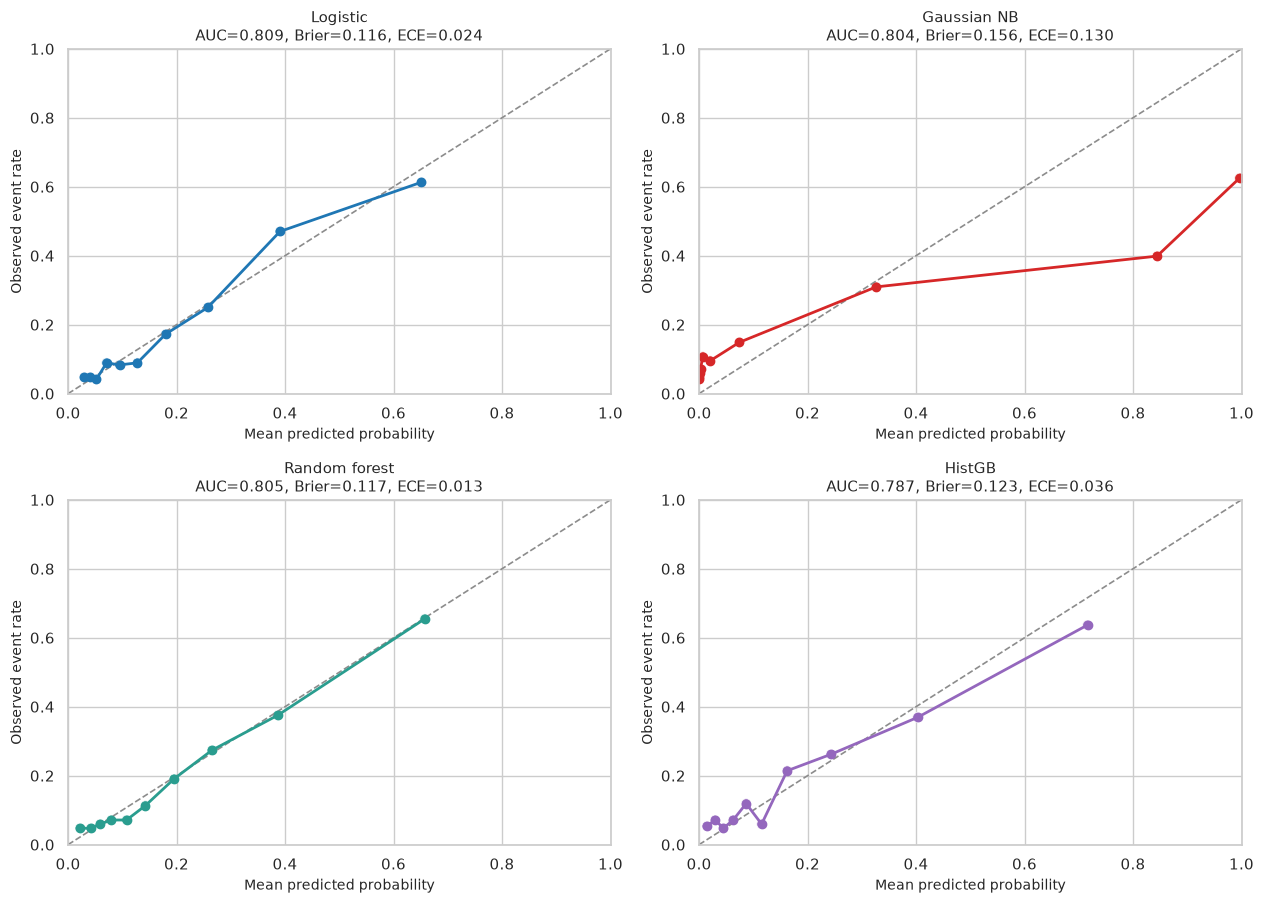

In [4]:

fig, axes = plt.subplots(2, 2, figsize=(12.8, 9.2))
axes = axes.flatten()
colors = ['#1f77b4', '#d62728', '#2a9d8f', '#9467bd']

for ax, name, color in zip(axes, models.keys(), colors):
    plot_reliability(
        ax,
        y_test,
        test_probs[name],
        title=(
            f"{name}\n"
            f"AUC={roc_auc_score(y_test, test_probs[name]):.3f}, "
            f"Brier={np.mean((test_probs[name] - y_test) ** 2):.3f}, "
            f"ECE={expected_calibration_error(y_test, test_probs[name]):.3f}"
        ),
        color=color,
        n_bins=10,
    )

plt.tight_layout()


The metric result should be read as an operating tradeoff. In Strong Ranking Does Not Guarantee Strong Probabilities, the best-looking score is useful only after we ask which error mode, subgroup, or capacity constraint it affects. The next step is to connect the metric with cost, risk, threshold choice, or the stakeholder decision.


### Discussion of the Base Models

A few patterns usually matter more than the exact numeric values.

First, the ROC AUC and average precision columns show which models are good at **ordering** cases. A model can be operationally useful for triage even if its probabilities are imperfect.

Second, the Brier score, log loss, reliability curve, and ECE diagnose whether those scores can be interpreted as risks. A model can achieve competitive AUC while still being visibly overconfident or underconfident across the probability range.

Third, the reliability curves should be read as shape diagnostics rather than beauty contests. Curves above the diagonal are underconfident in that region; curves below the diagonal are overconfident. Curvature near the middle can be especially important for decision-making because many operational policies are triggered by intermediate-risk ranges rather than extreme 0 or 1 probabilities.

This is where probability calibration earns its place. We do not recalibrate because a model is "bad". We recalibrate because a model may have useful ranking information while still misrepresenting the numeric magnitude of risk.


## 4. Post-Hoc Recalibration on a Held-Out Validation Set

A good recalibration workflow uses three distinct roles:

- `Train`: fit the original classifier,
- `Validation`: learn the recalibration map,
- `Test`: evaluate the recalibrated probabilities on untouched data.

That is crucial. If we learn a calibration map on the test set, then we are no longer auditing external probability quality; we are tuning to it.

We will choose a **high-discrimination but imperfectly calibrated** model from the validation results and compare three probability versions on the test set:

1. raw probabilities,
2. sigmoid / Platt-style recalibration,
3. isotonic recalibration.


In [5]:

validation_table = (
    metrics_table.loc[metrics_table['split'] == 'Validation']
    .sort_values('roc_auc', ascending=False)
    .reset_index(drop=True)
)

best_val_auc = validation_table['roc_auc'].max()
near_frontier = validation_table.loc[validation_table['roc_auc'] >= best_val_auc - 0.025].copy()
calibration_target = near_frontier.sort_values('ece', ascending=False).iloc[0]['model']

selection_summary = pd.DataFrame(
    {
        'selected_model': [calibration_target],
        'selection_rule': ['Highest ECE among models within 0.025 AUC of the validation leader'],
        'validation_auc': [validation_table.loc[validation_table['model'] == calibration_target, 'roc_auc'].iloc[0]],
        'validation_ece': [validation_table.loc[validation_table['model'] == calibration_target, 'ece'].iloc[0]],
    }
)
selection_summary


,selected_model,selection_rule,validation_auc,validation_ece
0,Gaussian NB,Highest ECE among models within 0.025 AUC of the validation leader,0.786,0.150


The metric result should be read as an operating tradeoff. In Post-Hoc Recalibration on a Held-Out Validation Set, the best-looking score is useful only after we ask which error mode, subgroup, or capacity constraint it affects. A performance number is useful after we ask what decision it would change.


In [6]:

raw_val = val_probs[calibration_target]
raw_test = test_probs[calibration_target]

sigmoid_calibrator = fit_sigmoid_calibrator(raw_val, y_val)
isotonic_calibrator = fit_isotonic_calibrator(raw_val, y_val)

test_prob_versions = {
    'Raw': raw_test,
    'Sigmoid calibrated': apply_sigmoid_calibrator(sigmoid_calibrator, raw_test),
    'Isotonic calibrated': isotonic_calibrator.predict(raw_test),
}

comparison_rows = []
for name, probs in test_prob_versions.items():
    comparison_rows.append({'version': name, **probability_metrics(y_test, probs)})

calibration_comparison_table = pd.DataFrame(comparison_rows).sort_values('brier_score').reset_index(drop=True)
calibration_comparison_table


,version,roc_auc,average_precision,brier_score,log_loss,ece,mean_predicted_risk,prevalence,calibration_slope,calibration_intercept
0,Sigmoid calibrated,0.804,0.529,0.120,0.387,0.026,0.190,0.190,1.004,0.011
1,Isotonic calibrated,0.799,0.496,0.121,0.404,0.024,0.187,0.190,0.828,-0.187
2,Raw,0.804,0.529,0.156,0.753,0.130,0.227,0.190,0.230,-1.046


The metric result should be read as an operating tradeoff. In Post-Hoc Recalibration on a Held-Out Validation Set, the best-looking score is useful only after we ask which error mode, subgroup, or capacity constraint it affects. The next step is to turn the score into an operating choice around cost, risk, threshold, or action.


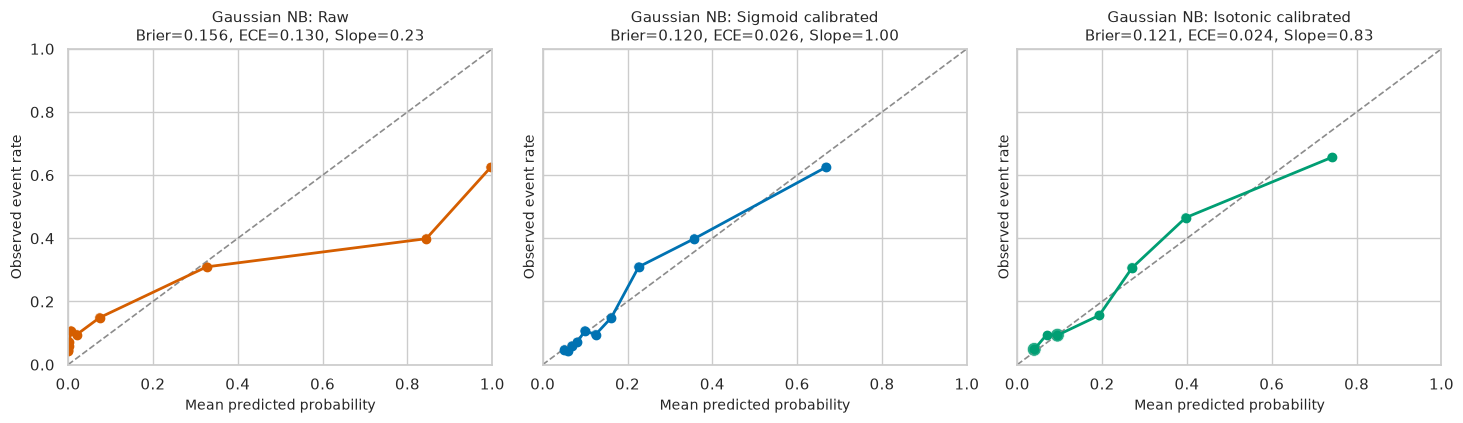

In [7]:
# Section focus: 4. Post-Hoc Recalibration on a Held-Out Validation Set.
# The code below keeps the calculation explicit so each intermediate step can be inspected.


fig, axes = plt.subplots(1, 3, figsize=(14.8, 4.4), sharex=True, sharey=True)
color_map = {
    'Raw': '#d55e00',
    'Sigmoid calibrated': '#0072b2',
    'Isotonic calibrated': '#009e73',
}

for ax, (label, probs) in zip(axes, test_prob_versions.items()):
    plot_reliability(
        ax,
        y_test,
        probs,
        title=(
            f"{calibration_target}: {label}\n"
            f"Brier={np.mean((probs - y_test) ** 2):.3f}, "
            f"ECE={expected_calibration_error(y_test, probs):.3f}, "
            f"Slope={calibration_slope_intercept(y_test, probs)[0]:.2f}"
        ),
        color=color_map[label],
        n_bins=10,
    )

axes[0].set_ylabel('Observed event rate')
plt.tight_layout()


The metric result should be read as an operating tradeoff. In Post-Hoc Recalibration on a Held-Out Validation Set, the best-looking score is useful only after we ask which error mode, subgroup, or capacity constraint it affects. The metric matters once it changes a cost tradeoff, risk tolerance, threshold, or stakeholder action.


### Discussion of Recalibration Results

This section should be read with two questions in mind.

First, did recalibration improve **probability quality**? Lower Brier score, lower log loss, smaller ECE, and a reliability curve closer to the 45-degree line all point in that direction.

Second, did recalibration materially distort **ranking quality**? A monotone sigmoid map preserves the score order exactly, so ROC AUC should remain essentially unchanged. Isotonic regression is also monotone, but because it can create ties, its discrimination can change slightly in finite samples. That is one reason to compare both discrimination and calibration metrics after recalibration rather than assuming improvement is free.

In practice, sigmoid calibration is often more stable on modest recalibration sets because it imposes a simple shape. Isotonic regression is more flexible and can fit local calibration patterns that a sigmoid cannot, but that flexibility can overfit when the recalibration sample is small.


## 5. Why Calibrated Probabilities Change Operational Decisions

Calibration becomes concrete when we ask what the scores are being used for. We will look at two decision-science use cases:

1. **portfolio planning**: do weekly expected event counts line up with reality?
2. **risk-band design**: within each score band, do the published risk levels mean what stakeholders think they mean?


,version,mean_expected_events_per_week,mean_actual_events_per_week,mean_bias,mae_events_per_week,rmse_events_per_week
0,Isotonic calibrated,26.206,26.667,-0.461,3.778,4.574
1,Sigmoid calibrated,26.568,26.667,-0.099,4.045,5.057
2,Raw,31.824,26.667,5.158,5.683,7.633


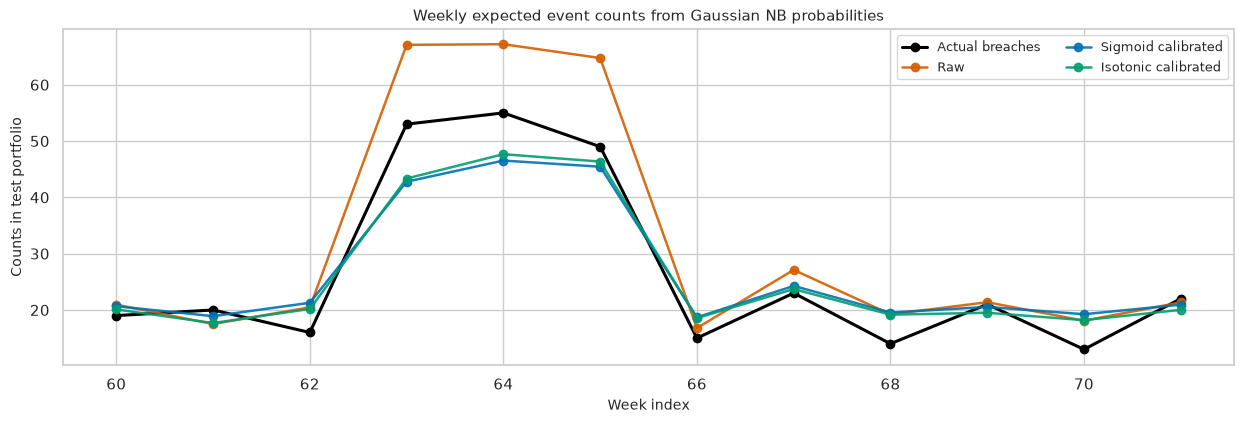

In [8]:
# Section focus: 5. Why Calibrated Probabilities Change Operational Decisions.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.


weekly_portfolio = (
    test_df[['week', target_col]]
    .rename(columns={target_col: 'actual_events'})
    .groupby('week', observed=False)
    .sum()
    .reset_index()
)

for label, probs in test_prob_versions.items():
    weekly_portfolio[label] = (
        test_df.assign(predicted_events=probs)
        .groupby('week', observed=False)['predicted_events']
        .sum()
        .to_numpy()
    )

fig, ax = plt.subplots(figsize=(12.6, 4.4))
ax.plot(weekly_portfolio['week'], weekly_portfolio['actual_events'], color='black', marker='o', linewidth=2.2, label='Actual breaches')
for label, color in color_map.items():
    ax.plot(weekly_portfolio['week'], weekly_portfolio[label], marker='o', linewidth=1.8, alpha=0.9, label=label, color=color)
ax.set_title(f'Weekly expected event counts from {calibration_target} probabilities')
ax.set_xlabel('Week index')
ax.set_ylabel('Counts in test portfolio')
ax.legend(ncol=2)
plt.tight_layout()

portfolio_error_table = []
for label in test_prob_versions:
    error = weekly_portfolio[label] - weekly_portfolio['actual_events']
    portfolio_error_table.append(
        {
            'version': label,
            'mean_expected_events_per_week': weekly_portfolio[label].mean(),
            'mean_actual_events_per_week': weekly_portfolio['actual_events'].mean(),
            'mean_bias': error.mean(),
            'mae_events_per_week': np.abs(error).mean(),
            'rmse_events_per_week': np.sqrt(np.mean(error ** 2)),
        }
    )

pd.DataFrame(portfolio_error_table).sort_values('mae_events_per_week').reset_index(drop=True)


This is the handoff from model evidence to an operating choice. The useful reading is which metric would change the action in Why Calibrated Probabilities Change Operational Decisions. The analyst should resolve metric conflict through the decision priority.


In [9]:
# Section focus: 5. Why Calibrated Probabilities Change Operational Decisions.
# The code below keeps the calculation explicit so each intermediate step can be inspected.


risk_band_edges = [0.0, 0.10, 0.20, 0.35, 1.01]
risk_band_labels = ['0-10%', '10-20%', '20-35%', '35%+']

band_rows = []
for version, probs in test_prob_versions.items():
    temp = pd.DataFrame({
        'prob': probs,
        'y': y_test,
    })
    temp['risk_band'] = pd.cut(temp['prob'], bins=risk_band_edges, labels=risk_band_labels, include_lowest=True, right=False)
    band_summary = (
        temp.groupby('risk_band', observed=False)
        .agg(
            accounts=('y', 'size'),
            mean_predicted_risk=('prob', 'mean'),
            observed_rate=('y', 'mean'),
        )
        .reset_index()
    )
    band_summary['version'] = version
    band_summary['abs_gap'] = (band_summary['mean_predicted_risk'] - band_summary['observed_rate']).abs()
    band_rows.append(band_summary)

risk_band_table = pd.concat(band_rows, ignore_index=True)
risk_band_table[['version', 'risk_band', 'accounts', 'mean_predicted_risk', 'observed_rate', 'abs_gap']]


,version,risk_band,accounts,mean_predicted_risk,observed_rate,abs_gap
0,Raw,0-10%,1136,0.012,0.077,0.065
1,Raw,10-20%,82,0.139,0.244,0.105
2,Raw,20-35%,58,0.268,0.207,0.061
3,Raw,35%+,404,0.846,0.498,0.348
4,Sigmoid calibrated,0-10%,759,0.069,0.058,0.011
5,Sigmoid calibrated,10-20%,455,0.140,0.134,0.006
6,Sigmoid calibrated,20-35%,215,0.266,0.326,0.059
7,Sigmoid calibrated,35%+,251,0.580,0.578,0.003
8,Isotonic calibrated,0-10%,1012,0.067,0.071,0.004
9,Isotonic calibrated,10-20%,172,0.194,0.157,0.037


The metric result should be read as an operating tradeoff. In Why Calibrated Probabilities Change Operational Decisions, the best-looking score is useful only after we ask which error mode, subgroup, or capacity constraint it affects. A metric earns its place when it changes a threshold, review rule, or deployment choice.


### Discussion of Operational Consequences

The portfolio-planning plot translates calibration into something managers immediately understand. If the model is well calibrated, summing predicted probabilities across the week's accounts should produce a reasonable approximation to the number of breaches that actually materialize. This calls for credible expected-risk arithmetic, not point-perfect weekly forecasts, so the model can support staffing and escalation planning.

The risk-band table tells a related story at a more local level. If the model labels a band as roughly `20-35%` risk, then the observed event rate in that band should be in the same neighborhood. A large gap means the organization is publishing risk language that does not match reality. That can lead to bad triage rules, confused stakeholders, and weak trust in model-based decisions.

This is why calibration has operational meaning. It changes whether the numbers behind the decisions are interpretable.


## 6. Practical Checklist for Risk-Score Calibration

Before trusting probability scores in an applied workflow, ask:

1. Is the model being used for **ranking only**, or for **numerical risk estimation**?
2. Are calibration diagnostics computed on a split that was **not** used to fit the base model?
3. Do the reliability curves show systematic overconfidence or underconfidence?
4. Are Brier score and log loss improving after recalibration alongside AUC?
5. Is the recalibration sample large enough to justify a flexible method like isotonic regression?
6. Do portfolio-level quantities such as expected counts or band-level event rates behave sensibly?
7. After deployment, is calibration rechecked under drift rather than assumed to remain fixed?


## Wrap-Up

Probability calibration sits at the boundary between prediction and decision. A model with strong discrimination may still be unsafe to interpret as a risk engine if its probabilities are numerically distorted. Reliability diagrams, Brier score, log loss, and simple recalibration methods help close that gap.

The main practical lesson is straightforward: if a score will be read as a probability, then it should be audited as a probability. That means evaluating whether predicted risks match observed frequencies, recalibrating when needed, and checking whether those revised probabilities improve actual operational use cases such as workload forecasting and risk-band design.

## References

- Chivers, C., Leung, B., & Yan, N. D. (2014). *Validation and calibration of probabilistic predictions in ecology*. Methods in Ecology and Evolution, 5(10), 1023-1032. [https://doi.org/10.1111/2041-210x.12238](https://doi.org/10.1111/2041-210x.12238)
- Fawcett, T., & Niculescu-Mizil, A. (2007). *PAV and the ROC convex hull*. Machine Learning, 68(1), 97-106. [https://doi.org/10.1007/s10994-007-5011-0](https://doi.org/10.1007/s10994-007-5011-0)
- Niculescu-Mizil, A., & Caruana, R. (2005). *Predicting good probabilities with supervised learning*. ICML. [https://doi.org/10.1145/1102351.1102430](https://doi.org/10.1145/1102351.1102430)
- Trottini, M., Campus, G., Corridore, D., et al. (2020). *Assessing the Predictive Performance of Probabilistic Caries Risk Assessment Models: The Importance of Calibration*. Caries Research, 54(3), 258-265. [https://doi.org/10.1159/000507276](https://doi.org/10.1159/000507276)
- Zadrozny, B., & Elkan, C. (2002). *Transforming classifier scores into accurate multiclass probability estimates*. KDD. [https://doi.org/10.1145/775047.775151](https://doi.org/10.1145/775047.775151)
